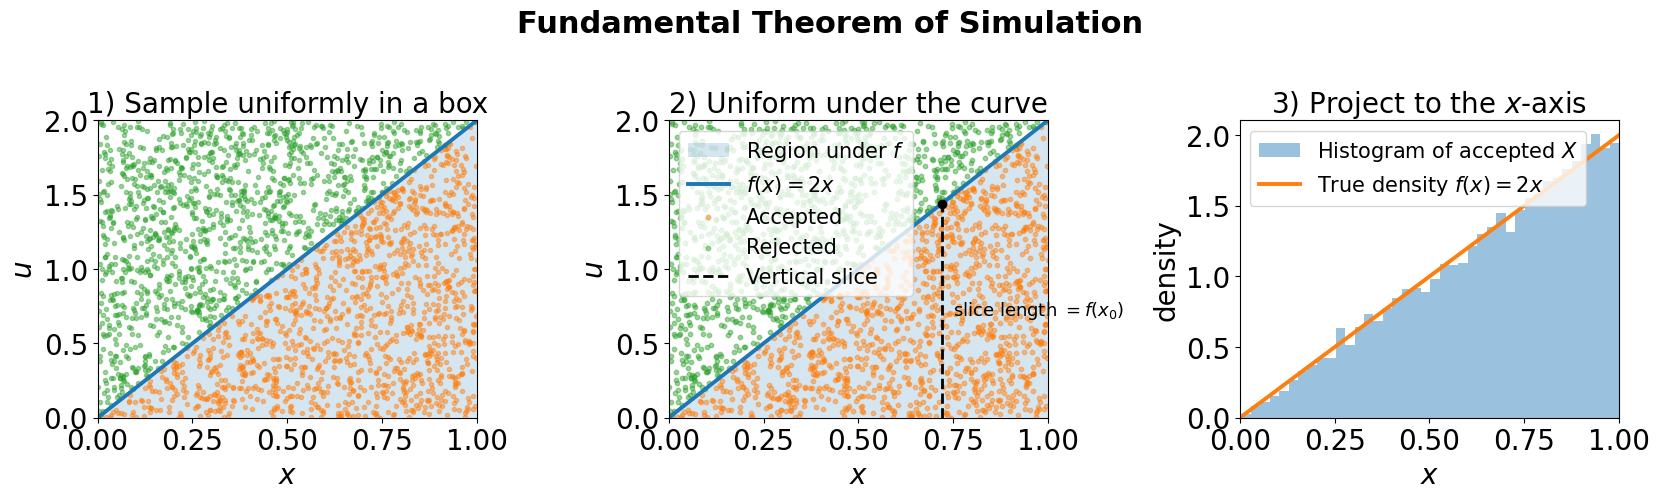

In [9]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 15,
})

def f(x):
    x = np.asarray(x)
    return np.where((0 <= x) & (x <= 1), 2*x, 0.0)

a, b = 0.0, 1.0
M = 2.0

rng = np.random.default_rng(7)
N = 30000

x_prop = rng.uniform(a, b, N)
u_prop = rng.uniform(0, M, N)

accept = u_prop <= f(x_prop)
x_acc = x_prop[accept]
u_acc = u_prop[accept]

xg = np.linspace(a, b, 500)
fg = f(xg)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))

# =========================
# Panel 1
# =========================
ax = axes[0]
ax.fill_between(xg, 0, fg, alpha=0.18)
ax.plot(xg, fg, lw=2.8, label=r"$f(x)=2x$")

show = 2500

ax.scatter(
    x_prop[:show][accept[:show]],
    u_prop[:show][accept[:show]],
    s=9,
    alpha=0.45,
)
ax.scatter(
    x_prop[:show][~accept[:show]],
    u_prop[:show][~accept[:show]],
    s=9,
    alpha=0.45,
)
ax.set_title("1) Sample uniformly in a box")
ax.set_xlabel("$x$")
ax.set_ylabel("$u$")
ax.set_xlim(a, b)
ax.set_ylim(0, M)

# =========================
# Panel 2
# =========================
ax = axes[1]
ax.fill_between(xg, 0, fg, alpha=0.18, label="Region under $f$")
ax.plot(xg, fg, lw=2.8, label=r"$f(x)=2x$")

ax.scatter(
    x_prop[:show][accept[:show]],
    u_prop[:show][accept[:show]],
    s=10,
    alpha=0.45,
    label="Accepted",
)
ax.scatter(
    x_prop[:show][~accept[:show]],
    u_prop[:show][~accept[:show]],
    s=10,
    alpha=0.45,
    label="Rejected",
)

x0 = 0.72
fx0 = float(f(x0))
ax.vlines(x0, 0, fx0, color="black", lw=2, linestyles="--", label="Vertical slice")
ax.scatter([x0], [fx0], color="black", s=35, zorder=5)

ax.text(
    x0 + 0.03,
    fx0 / 2,
    r"slice length $=f(x_0)$",
    va="center",
    fontsize=13,
)

ax.set_title("2) Uniform under the curve")
ax.set_xlabel("$x$")
ax.set_ylabel("$u$")
ax.set_xlim(a, b)
ax.set_ylim(0, M)
ax.legend(frameon=True, loc="upper left")

# =========================
# Panel 3
# =========================
ax = axes[2]
ax.hist(
    x_acc,
    bins=40,
    density=True,
    alpha=0.45,
    label="Histogram of accepted $X$",
)
ax.plot(xg, fg, lw=2.8, label=r"True density $f(x)=2x$")

ax.set_title("3) Project to the $x$-axis")
ax.set_xlabel("$x$")
ax.set_ylabel("density")
ax.set_xlim(a, b)
ax.legend(frameon=True, loc="upper left")

fig.suptitle("Fundamental Theorem of Simulation", fontsize=22, fontweight="bold")

fig.tight_layout()
fig.savefig("fts_simple_example.pdf", bbox_inches="tight", dpi=300)
plt.show()